In [1]:
import numpy as np
import os
from glob import glob
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
import seaborn as sns
import time
import os
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
train_path = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/train"
valid_path = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/valid"
test_path = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/test"

In [4]:
# Config
img_size = (224, 224)
input_shape = (224, 224, 3)
batch_size = 64
epochs = 100
num_classes = 4

train_datagen = ImageDataGenerator(
    dtype='float32',
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)
val_datagen = ImageDataGenerator(
    dtype='float32',

)
test_datagen = ImageDataGenerator(
    dtype='float32',
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
    shuffle = False,
)

validation_generator = val_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
)

Found 613 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Found 72 images belonging to 4 classes.


['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


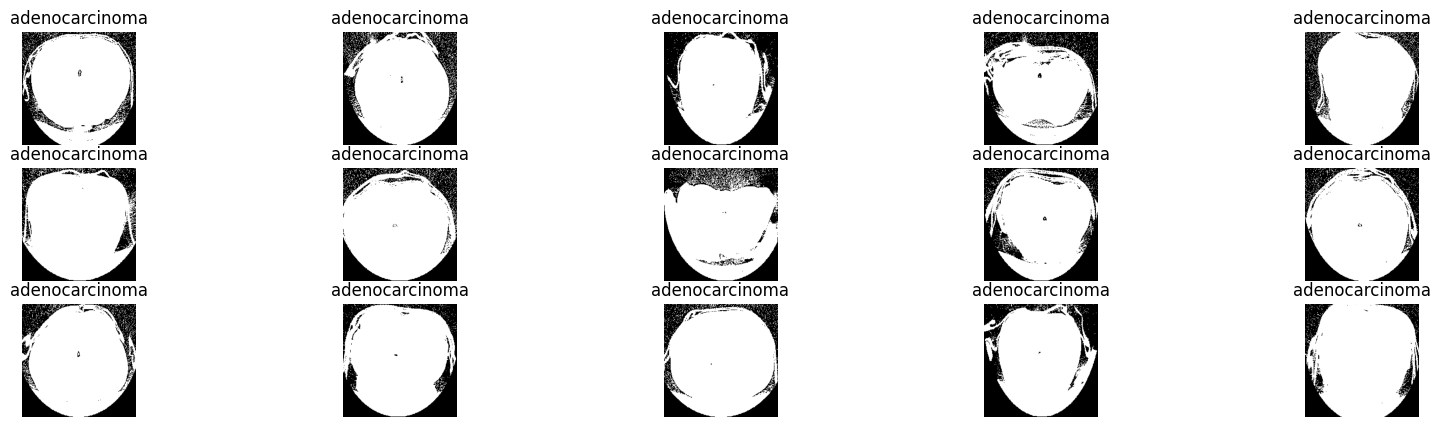

In [5]:
class_names=list(test_generator.class_indices.keys())
print(class_names)

fig = plt.figure(figsize=(20,5))

image_batch,label_batch = test_generator[1]
for i in range(15):
    ax = fig.add_subplot(3,5,i+1,xticks = [], yticks = [])
    ax.imshow(image_batch[i])
    plt.axis('off')
    plt.title(class_names[np.argmax(label_batch[i])])

In [7]:
def build_alexnet():
    # Define input layer
    inputs = Input(shape=(224, 224, 3))

    # Conv1
    x = Conv2D(96, (11, 11), strides=4, padding='valid', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2)(x)

    # Conv2
    x = Conv2D(256, (5, 5), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2)(x)

    # Conv3
    x = Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Conv4
    x = Conv2D(384, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # Conv5
    x = Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2)(x)

    # FC layers
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(4, activation='softmax')(x)  # Adjusted for 4 classes

    # Create model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [8]:
# Callback
checkpoint = ModelCheckpoint(filepath='/content/drive/MyDrive/KLTN/AlexNet/Models/chest_CT_SCAN-AlexNet.h5',
                            monitor='val_loss',
                            mode='auto',
                            save_best_only=True)

early_stopping = EarlyStopping(monitor='val_loss', patience=15, verbose=1, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [9]:
# Khởi tạo mô hình
model = build_alexnet()

# Đo thời gian huấn luyện
start_time = time.time()

# Huấn luyện
history = model.fit(
    train_generator,
    steps_per_epoch=20,
    epochs=epochs,
    verbose=1,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping, lr_scheduler]
)

training_time = time.time() - start_time

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.3886 - loss: 2.8955

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.4137 - loss: 2.8319 - val_accuracy: 0.1806 - val_loss: 45.7048 - learning_rate: 1.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5056 - loss: 1.9530 - val_accuracy: 0.1806 - val_loss: 50.4091 - learning_rate: 1.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 624ms/step - accuracy: 0.4940 - loss: 1.5494 - val_accuracy: 0.1806 - val_loss: 50.9035 - learning_rate: 1.0000e-04
Epoch 4/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5531 - loss: 1.1823

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5498 - loss: 1.2153 - val_accuracy: 0.1806 - val_loss: 31.8299 - learning_rate: 1.0000e-04
Epoch 5/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5600 - loss: 1.2063

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7267 - loss: 0.6221 - val_accuracy: 0.6806 - val_loss: 0.6326 - learning_rate: 5.0000e-05
Epoch 29/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.7238 - loss: 0.7380

20/20 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.7444 - loss: 0.7389 - val_accuracy: 0.7639 - val_loss: 0.6163 - learning_rate: 5.0000e-05
Epoch 30/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 584ms/step - accuracy: 0.7815 - loss: 0.5228 - val_accuracy: 0.6944 - val_loss: 0.7113 - learning_rate: 5.0000e-05
Epoch 31/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 616ms/step - accuracy: 0.7963 - loss: 0.5937 - val_accuracy: 0.7639 - val_loss: 0.6647 - learning_rate: 5.0000e-05
Epoch 32/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8028 - loss: 0.5566

20/20 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7921 - loss: 0.5565 - val_accuracy: 0.7639 - val_loss: 0.5279 - learning_rate: 5.0000e-05
Epoch 33/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7843 - loss: 0.6183 - val_accuracy: 0.7639 - val_loss: 0.6268 - learning_rate: 5.0000e-05
Epoch 34/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 623ms/step - accuracy: 0.7940 - loss: 0.5301 - val_accuracy: 0.7639 - val_loss: 0.5387 - learning_rate: 5.0000e-05
Epoch 35/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 541ms/step - accuracy: 0.7832 - loss: 0.4961 - val_accuracy: 0.7639 - val_loss: 0.5634 - learning_rate: 5.0000e-05
Epoch 36/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 583ms/step - accuracy: 0.8032 - loss: 0.5497 - val_accuracy: 0.7917 - val_loss: 0.5500 - learning_rate: 2.5000e-05
Epoch 37/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8254 - loss: 0.4494

20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 844ms/step - accuracy: 0.8270 - loss: 0.4441 - val_accuracy: 0.7778 - val_loss: 0.5104 - learning_rate: 2.5000e-05
Epoch 38/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.8236 - loss: 0.4276

20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8204 - loss: 0.4368 - val_accuracy: 0.8056 - val_loss: 0.4650 - learning_rate: 2.5000e-05
Epoch 39/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 36s 633ms/step - accuracy: 0.8010 - loss: 0.4642 - val_accuracy: 0.7639 - val_loss: 0.4889 - learning_rate: 2.5000e-05
Epoch 40/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 593ms/step - accuracy: 0.8148 - loss: 0.5195 - val_accuracy: 0.7917 - val_loss: 0.4697 - learning_rate: 2.5000e-05
Epoch 41/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 595ms/step - accuracy: 0.8083 - loss: 0.5003 - val_accuracy: 0.7639 - val_loss: 0.5213 - learning_rate: 2.5000e-05
Epoch 42/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 591ms/step - accuracy: 0.8099 - loss: 0.4903 - val_accuracy: 0.8056 - val_loss: 0.4858 - learning_rate: 1.2500e-05
Epoch 43/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 598ms/step - accuracy: 0.7899 - loss: 0.4653 - val_accuracy: 0.7778 - val_loss: 0.4747 - learning_rate: 1.2500e-05
Epoch 44/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 615ms/step - accur

In [10]:
# Đánh giá trên test
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6514 - loss: 0.8627

Test Accuracy: 0.6254
Test Loss: 0.9040


In [11]:
# Dự đoán
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# In các chỉ số
print(f"Accuracy:  {accuracy_score(y_true, y_pred_classes):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_classes, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_classes, average='macro'):.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 692ms/step
Accuracy:  0.6254
Precision: 0.7115
Recall:    0.7013


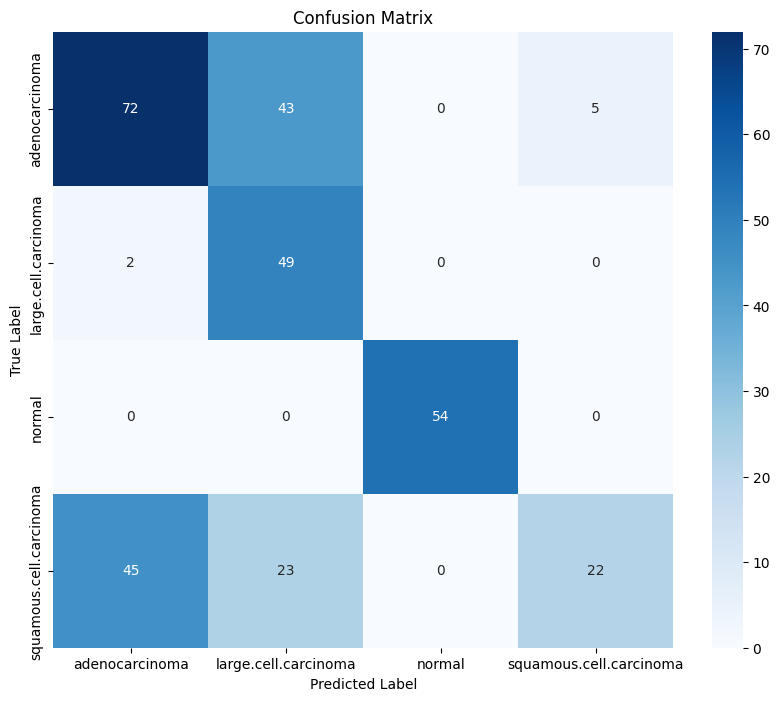

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma       0.61      0.60      0.60       120
   large.cell.carcinoma       0.43      0.96      0.59        51
                 normal       1.00      1.00      1.00        54
squamous.cell.carcinoma       0.81      0.24      0.38        90

               accuracy                           0.63       315
              macro avg       0.71      0.70      0.64       315
           weighted avg       0.70      0.63      0.60       315



In [12]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

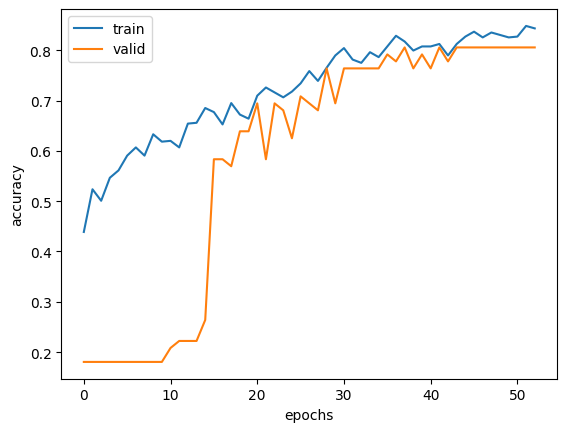

In [13]:
# Vẽ biểu đồ accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.legend(loc='upper left')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

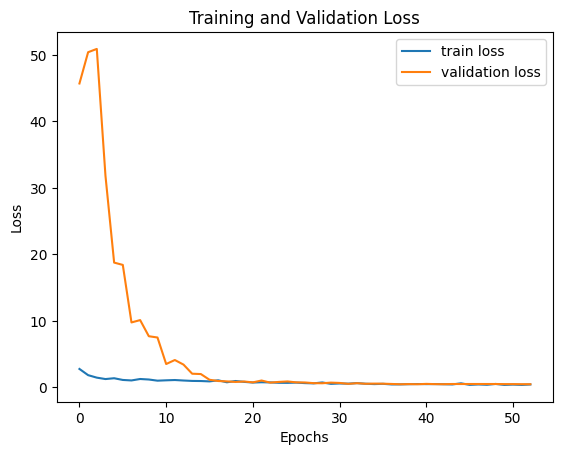

In [14]:
# Vẽ biểu đồ loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [15]:
# Tính các chỉ số đánh giá
val_loss = history.history['val_loss'][-1]  # Categorical Crossentropy trên tập validation
# Số lượng epoch thực tế
epochs_trained = len(history.history['loss'])
# Số lượng mẫu trong tập train
num_samples = train_generator.samples
# Số đặc trưng (features) - kích thước ảnh (224, 224, 3)
num_features = np.prod(input_shape)

In [16]:
# In kết quả
print("Chỉ số:")
print(f"Loss Function (Categorical Crossentropy): {val_loss:.4f}")
print(f"Thời gian huấn luyện: {training_time:.2f} giây")
print(f"Số lượng epoch: {epochs_trained}")
print(f"Số lượng mẫu: {num_samples}")
print(f"Số đặc trưng: {num_features}")

Chỉ số:
Loss Function (Categorical Crossentropy): 0.4721
Thời gian huấn luyện: 1366.26 giây
Số lượng epoch: 53
Số lượng mẫu: 613
Số đặc trưng: 150528
